In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd

In [44]:
#  ------------------------------------------ Seaborn Setup & Styling ------------------------------------------

# set theme 
sns.set_theme(style="ticks")

# set context and font scale
sns.set_context("paper", font_scale=1.2)

# set color palette
sns.set_palette("colorblind")

# load the Titanic dataset for practice
df = sns.load_dataset("titanic")

# check if the dataset is loaded correctly
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


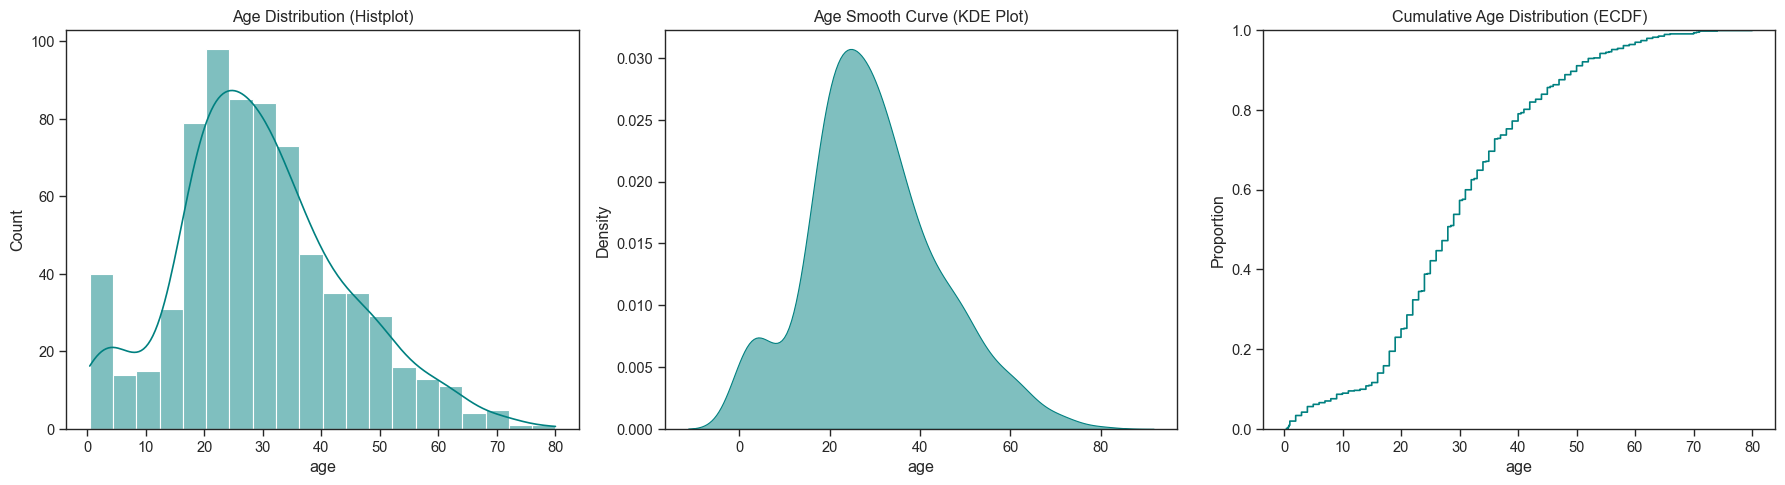

In [45]:

# set up the figure and axes for the three plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ১. Histplot (histogram and KDE combined)
sns.histplot(data=df, x="age", kde=True, color="teal", ax=axes[0])
axes[0].set_title("Age Distribution (Histplot)")

# ২. KDE Plot (smooth curve)
sns.kdeplot(data=df, x="age", fill=True, alpha=0.5, color="teal", ax=axes[1])
axes[1].set_title("Age Smooth Curve (KDE Plot)")

# ৩. ECDF Plot (cumulative distribution)
sns.ecdfplot(data=df, x="age", color="teal", ax=axes[2])
axes[2].set_title("Cumulative Age Distribution (ECDF)")

# adjust layout and display the plots
plt.tight_layout()
plt.show()

Seaborn Relational Plots

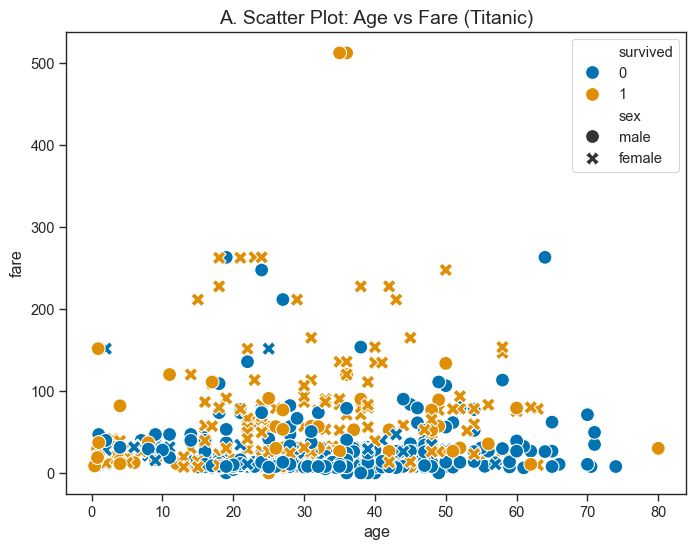

In [46]:
# ------------------------------------------ Scatter Plot ------------------------------------------

# set theme and context for relational plots
sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("colorblind")

# load the Titanic dataset for scatter and relational plots
df_titanic = sns.load_dataset("titanic")



plt.figure(figsize=(8, 6)) # create a separate figure for the scatter plot
scatter = sns.scatterplot(
    data=df_titanic,
    x="age",
    y="fare",
    hue="survived",  # Color by survival status
    style="sex",     # Style by sex
    s=100,           # Size of the points
    legend="full"
)
scatter.set_title("A. Scatter Plot: Age vs Fare (Titanic)", fontsize=14)
plt.show()


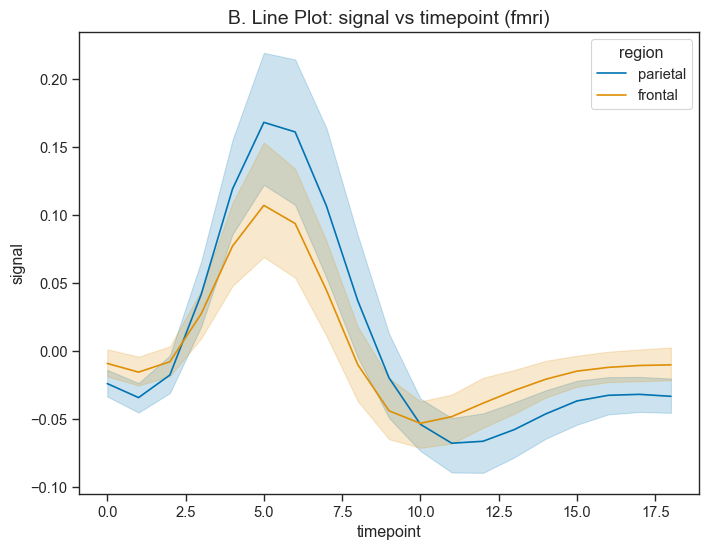

In [47]:
#  ------------------------------------------ Line Plot (FMRI Data) ------------------------------------------

# load the FMRI dataset for line plots
df_fmri = sns.load_dataset("fmri")

plt.figure(figsize=(8, 6)) # ]create a separate figure for the line plot
line = sns.lineplot(
    data=df_fmri,
    x="timepoint",    
    y="signal",       
    hue="region",     
    markers=True,     
    dashes=False      
)
line.set_title("B. Line Plot: signal vs timepoint (fmri)", fontsize=14)
plt.show()



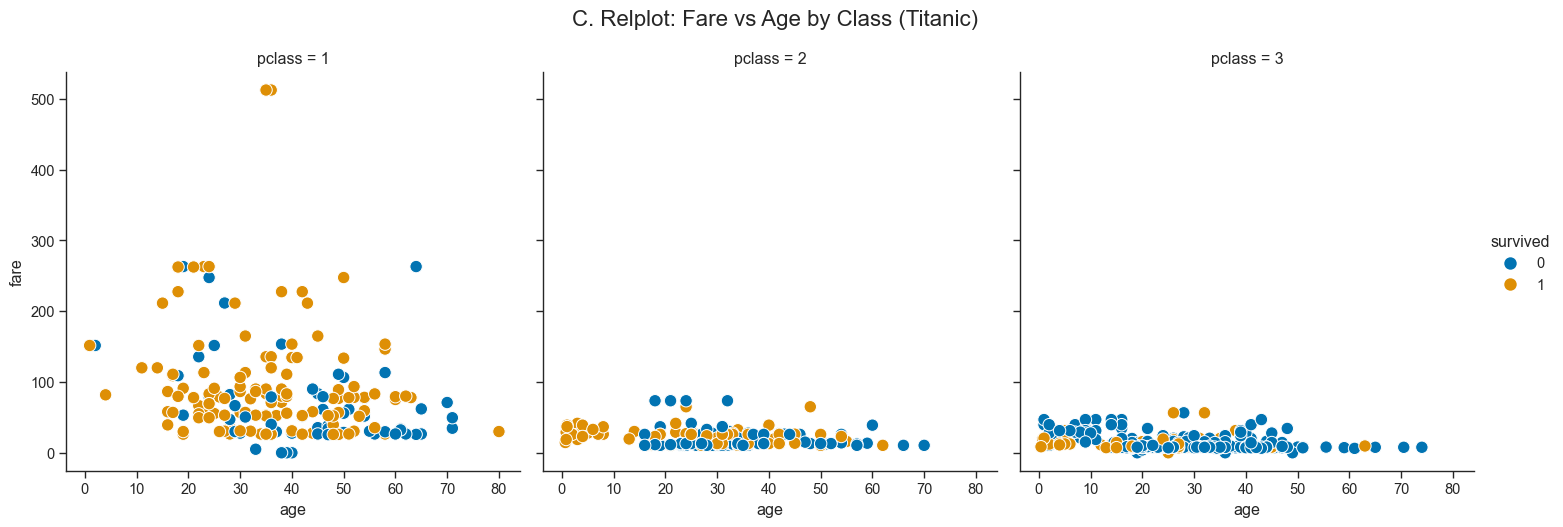

In [48]:
# ------------------------------------------ Relplot: Fare vs Age by Class (Titanic Data) ------------------------------------------


rel = sns.relplot(
    data=df_titanic,
    x="age",
    y="fare",
    hue="survived",
    col="pclass",    # create separate columns for each passenger class
    kind="scatter",  # scatter plot
    s=80             # size of the points
)
rel.figure.suptitle("C. Relplot: Fare vs Age by Class (Titanic)", fontsize=16, y=1.05)
plt.show()

Categorical Plots

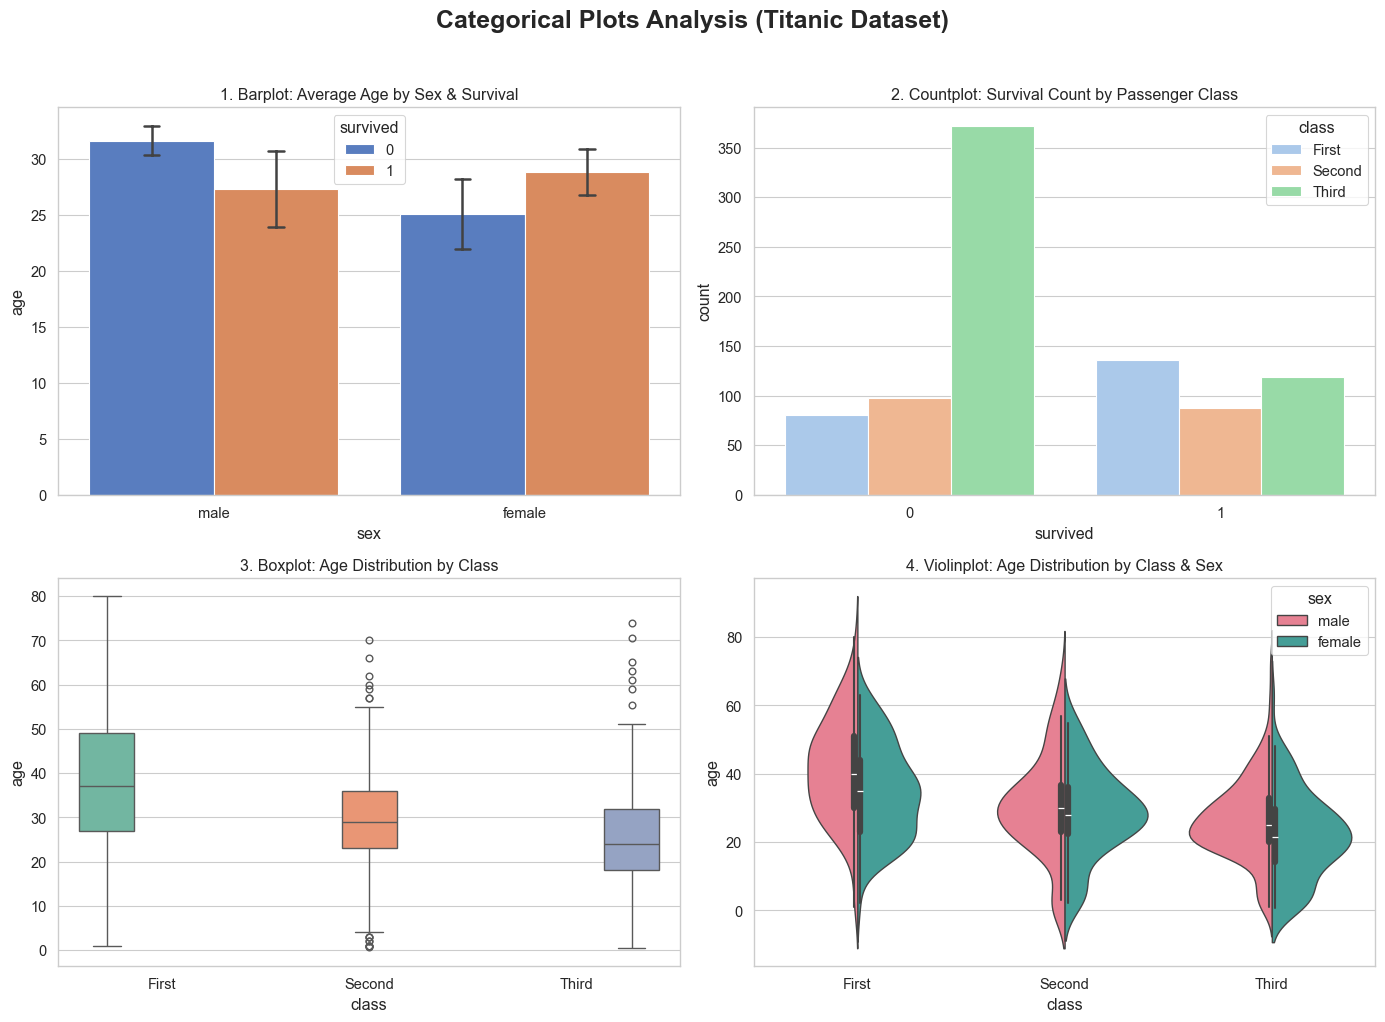

In [49]:
# ------------------------------------------ Categorical Plots: Barplot, Countplot, Boxplot, Violinplot ------------------------------------------

# set theme and context for categorical plots
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)

# load the Titanic dataset for categorical plots
df = sns.load_dataset("titanic")

# set up a 2x2 grid for the categorical plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle("Categorical Plots Analysis (Titanic Dataset)", fontsize=18, fontweight='bold', y=1.02)

# 1. Barplot (Average Values and Error Bars)
sns.barplot(data=df, x="sex", y="age", hue="survived", capsize=.1, ax=axes[0, 0], palette="muted")
axes[0, 0].set_title("1. Barplot: Average Age by Sex & Survival")

# 2. Countplot (Total Count)
sns.countplot(data=df, x="survived", hue="class", ax=axes[0, 1], palette="pastel")
axes[0, 1].set_title("2. Countplot: Survival Count by Passenger Class")

# 3. Boxplot (Outliers and Data Distribution)
sns.boxplot(data=df, x="class", y="age", hue="class", palette="Set2", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("3. Boxplot: Age Distribution by Class")

# 4. Violinplot (KDE + Boxplot Combination)
# split=True for separate plots for each category in hue="sex"
sns.violinplot(data=df, x="class", y="age", hue="sex", split=True, palette="husl", ax=axes[1, 1])
axes[1, 1].set_title("4. Violinplot: Age Distribution by Class & Sex")

# layout fix and display
plt.tight_layout()
plt.show()

Matrix plot

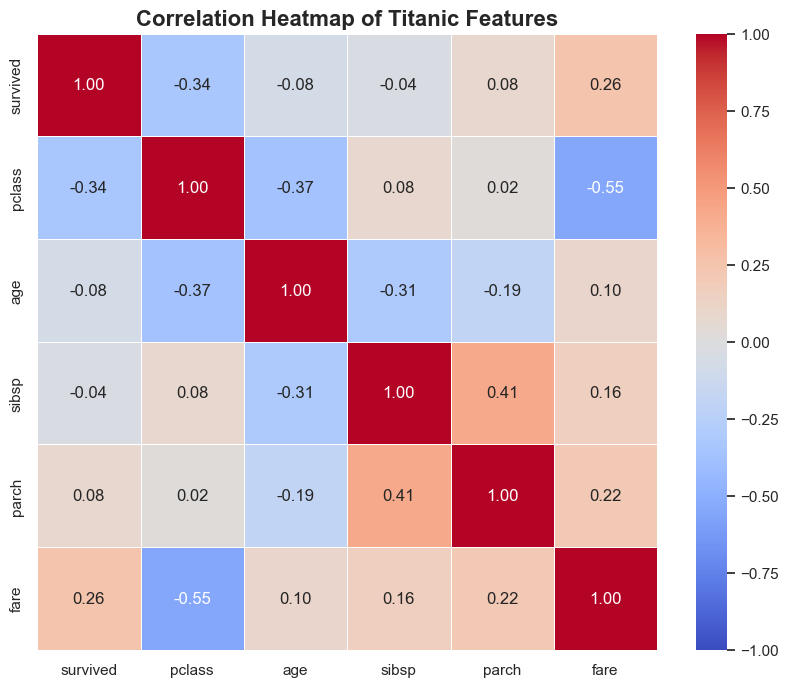

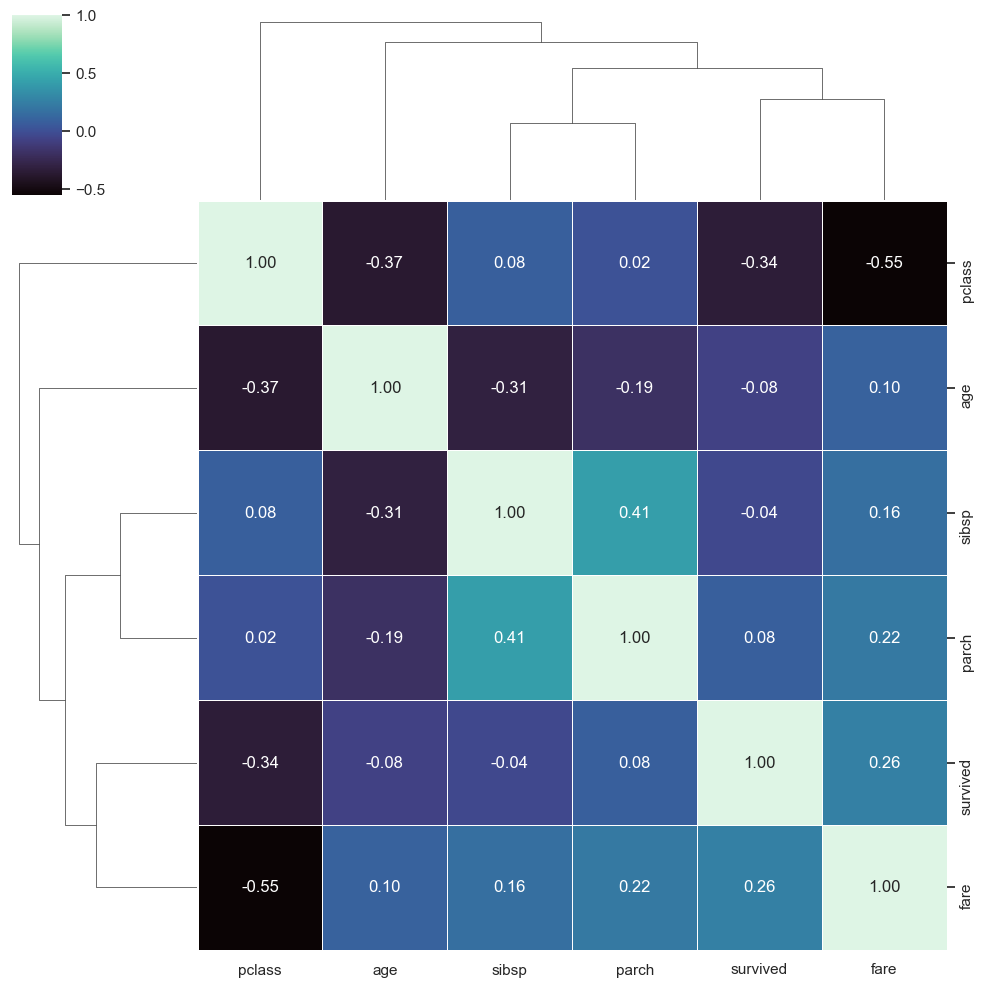

In [50]:
# ------------------------------------------ Correlation Heatmap & Clustermap ------------------------------------------

# set theme for heatmap and clustermap
sns.set_theme(style="white")

# load the Titanic dataset for correlation analysis
df = sns.load_dataset("titanic")

# Only select numeric data for correlation analysis (to avoid errors with non-numeric columns)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()


# Heatmap
plt.figure(figsize=(10, 8))
# When annot=True, it will display the correlation values inside the boxes, and fmt=".2f" formats the numbers to 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Titanic Features", fontsize=16, fontweight='bold')
plt.show()


# Clustermap
# note: clustermap will create a whole figure on its own, so no need for plt.figure() before it
sns.clustermap(corr_matrix, cmap='mako', annot=True, fmt=".2f", linewidths=.5, figsize=(10, 10))
plt.show()

Multi-plot grid

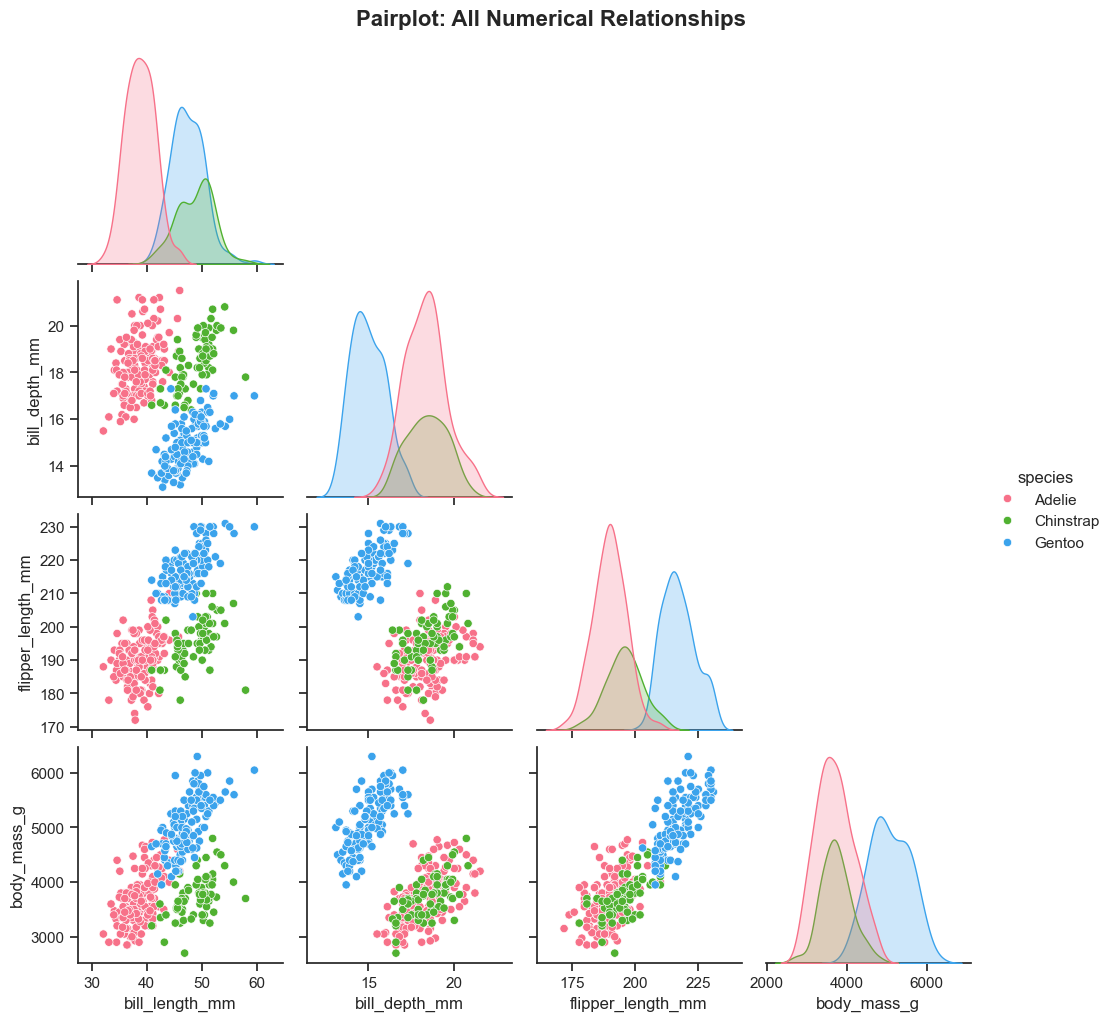

In [51]:
# ------------------------------------------ Pairplot (Penguins Dataset) ------------------------------------------
sns.set_theme(style="ticks")

# load the Penguins dataset for pairplot
df = sns.load_dataset("penguins")

# pairplot with hue for species and corner=True to avoid duplicate plots
# if corner=True, it will remove the upper triangle of the pairplot, which contains duplicate plots,
# making it cleaner and more professional-looking
sns.pairplot(df, hue="species", corner=True, palette="husl") 
plt.suptitle("Pairplot: All Numerical Relationships", y=1.02, fontsize=16, fontweight='bold')
plt.show()



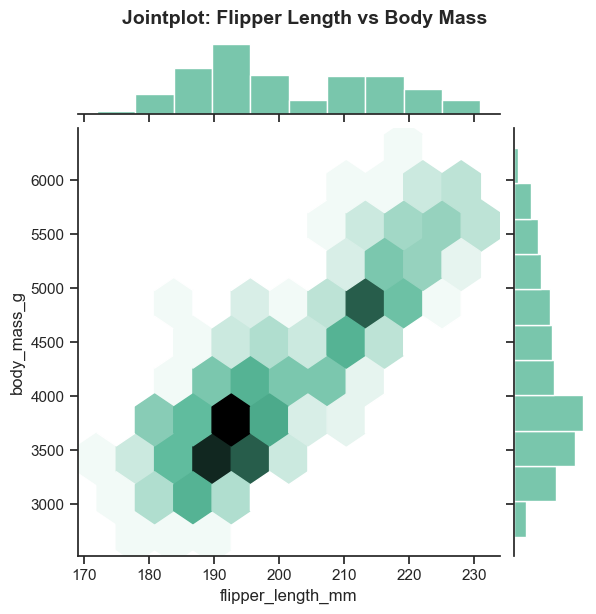

In [52]:
#  ----------------------------------- Jointplot (Scatter + Histogram) -----------------------------------

# if kind="hex", it will create a hexbin plot, which is a type of bivariate histogram that uses hexagonal bins to show the density of data points.
# This is especially useful when you have a large number of data points, as it prevents overplotting 
# and makes it easier to visualize the distribution and relationship between the two variables.
joint = sns.jointplot(data=df, x="flipper_length_mm", y="body_mass_g", kind="hex", color="#4CB391")
joint.figure.suptitle("Jointplot: Flipper Length vs Body Mass", y=1.02, fontsize=14, fontweight='bold')
plt.show()


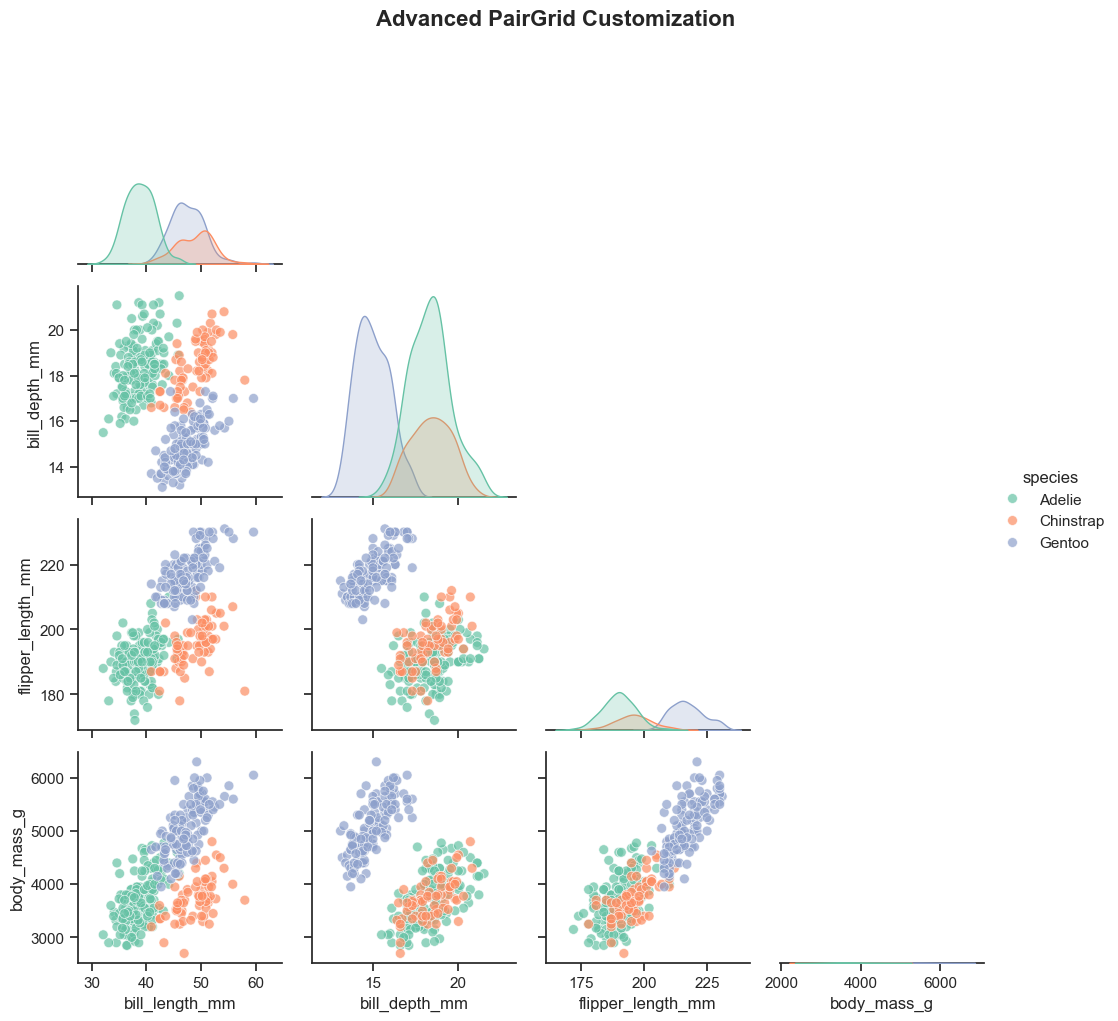

In [53]:
# ---------------------------------- pairGrid with Advanced Customization ----------------------------------

# first we create an empty grid
g = sns.PairGrid(df, hue="species", corner=True, palette="Set2")

# second, we map the desired plots to the diagonal and off-diagonal areas of the grid
g.map_diag(sns.kdeplot, fill=True)

# lastly, we customize the off-diagonal scatter plots with specific aesthetics like size, transparency, and edge color
g.map_offdiag(sns.scatterplot, s=50, alpha=0.7, edgecolor="white")

g.add_legend()
g.figure.suptitle("Advanced PairGrid Customization", y=1.02, fontsize=16, fontweight='bold')
plt.show()

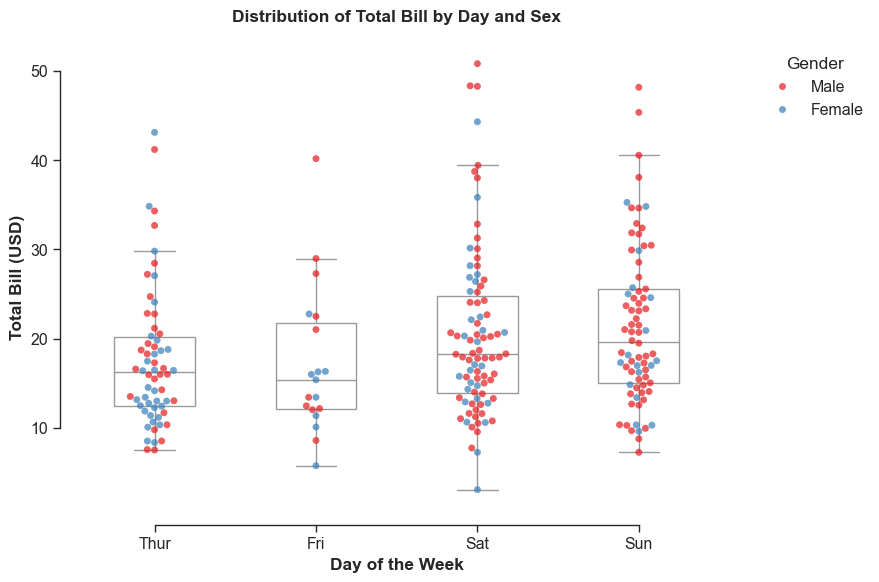

In [54]:

sns.set_theme(style="ticks", context="paper", font_scale=1.3)

# ২. loading the dataset
df = sns.load_dataset("tips")

# setting the figure size for better visibility
plt.figure(figsize=(9, 6))

# creating boxplot with customizations
# showfliers=False outliers will not be shown, width=0.5 makes the boxes thinner
# zorder=1 shows the boxplot below the swarmplot, so the dots will be on top of the boxes
sns.boxplot(data=df, x="day", y="total_bill", color="white", showfliers=False, width=0.5, zorder=1)

# creating swarmplot with customizations
# alpha=0.7 makes the dots slightly transparent, size=5 makes the dots smaller
# zorder=2 ensures that the swarmplot is drawn on top of the boxplot, making the individual data points visible
sns.swarmplot(data=df, x="day", y="total_bill", hue="sex", palette="Set1", alpha=0.7, size=5, zorder=2)

# title and labels with custom font weight and padding for better aesthetics
plt.title("Distribution of Total Bill by Day and Sex", fontweight='bold', pad=15)
plt.xlabel("Day of the Week", fontweight='bold')
plt.ylabel("Total Bill (USD)", fontweight='bold')

# deleting the top and right spines for a cleaner look
# offset=10 gives some space between the axis and the spines, making the plot look less cramped
# trim=True removes the spines only up to the last data point, which can make the plot look more balanced
sns.despine(trim=True, offset=10)

# customizing the legend to make it more informative and visually appealing
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

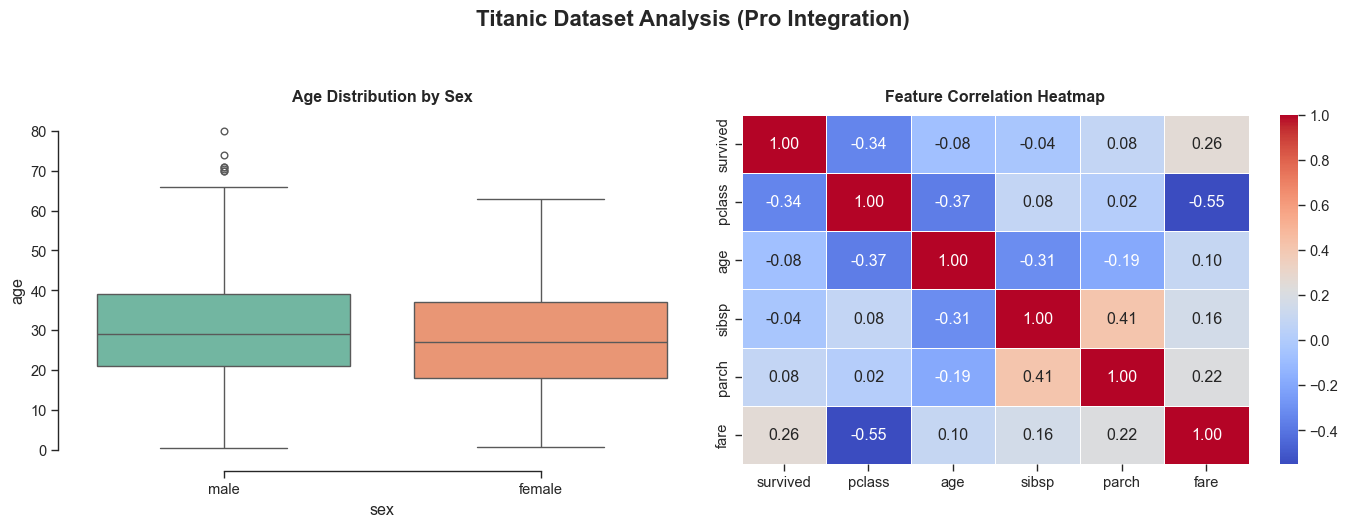

In [55]:


sns.set_theme(style="ticks", context="paper", font_scale=1.2)

df = sns.load_dataset("titanic")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig.suptitle("Titanic Dataset Analysis (Pro Integration)", fontsize=16, fontweight='bold', y=1.05)


sns.boxplot(data=df, x="sex", y="age", hue="sex", palette="Set2", legend=False, ax=axes[0])


numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])



axes[0].set_title("Age Distribution by Sex", fontweight='bold', pad=10)
axes[1].set_title("Feature Correlation Heatmap", fontweight='bold', pad=10)


sns.despine(ax=axes[0], trim=True, offset=5)


plt.tight_layout()


plt.savefig("pro_research_figure.pdf", bbox_inches='tight') 
plt.savefig("pro_research_figure.png", dpi=300, bbox_inches='tight')


plt.show()

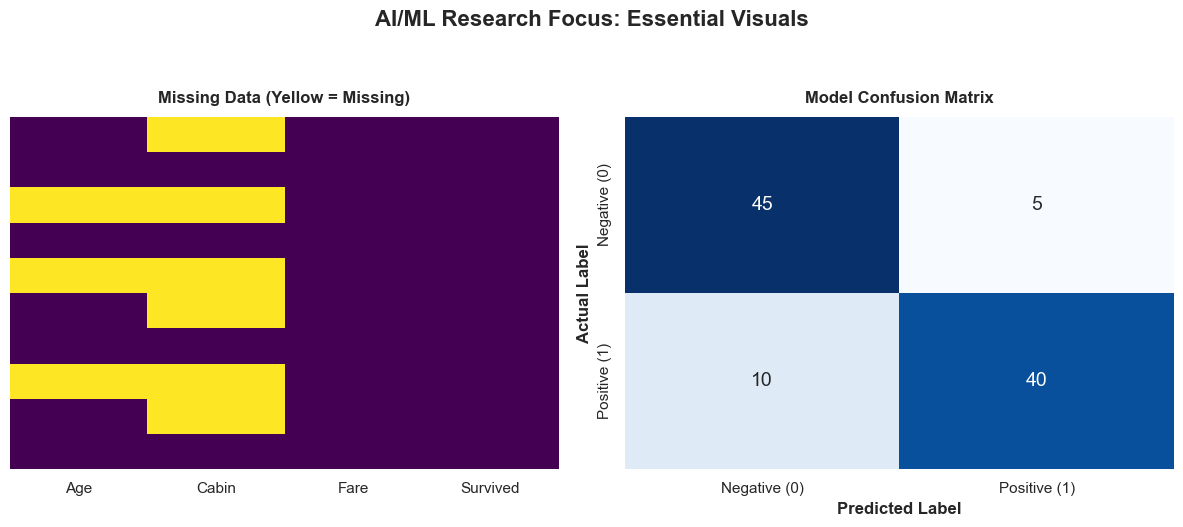

In [ ]:

sns.set_theme(style="white")


# creating a sample dataset with missing values and a confusion matrix for demonstration
data = {
    'Age': [22, 38, np.nan, 35, np.nan, 28, 50, np.nan, 25, 40],
    'Cabin': [np.nan, 'C85', np.nan, 'C123', np.nan, np.nan, 'E46', np.nan, np.nan, 'B22'],
    'Fare': [7.25, 71.28, 7.92, 53.1, 8.05, 8.45, 51.86, 21.07, 10.5, 30.0],
    'Survived': [0, 1, 1, 1, 0, 0, 0, 1, 0, 1]
}
df = pd.DataFrame(data)

# confusion matrix data (for a binary classification model)
# [[True Negative, False Positive],
#  [False Negative, True Positive]]
cm = np.array([[45, 5], 
               [10, 40]])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("AI/ML Research Focus: Essential Visuals", fontsize=16, fontweight='bold', y=1.05)



sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Missing Data (Yellow = Missing)", fontweight='bold', pad=10)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1], annot_kws={"size": 14})
axes[1].set_title("Model Confusion Matrix", fontweight='bold', pad=10)
axes[1].set_xlabel("Predicted Label", fontweight='bold')
axes[1].set_ylabel("Actual Label", fontweight='bold')


axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'])
axes[1].set_yticklabels(['Negative (0)', 'Positive (1)'])


plt.tight_layout()


plt.savefig("ml_research_visuals.pdf", bbox_inches='tight')
plt.savefig("ml_research_visuals.png", dpi=300, bbox_inches='tight')


plt.show()